# 🏠 DDR (Detailed Diagnostic Report) Generator
### AI-Powered — **100% FREE, No Credit Card Needed**

---

## 🆓 Free AI Options:

| # | Provider | Model | Speed | Sign-up Link |
|---|----------|-------|-------|--------------|
| **A ⭐** | **Groq** | llama3-8b | ⚡ Very Fast | https://console.groq.com |
| **B** | **HuggingFace** | Mistral-7B | 🐢 Slower | https://huggingface.co/settings/tokens |
| **C** | **Ollama (local)** | llama3 | varies | No key needed |

> ⭐ **Recommended: Groq** — Free, no credit card, very fast. Sign up takes 30 seconds.

---

**Steps:**
1. Run Cell 1 → install packages
2. Cell 2 → pick provider, paste free key
3. Cell 4 → upload your PDF(s)
4. Run remaining cells → download DDR report

## 🚀 Push to GitHub

To push this notebook to your GitHub repository, please follow these steps.

### Step 1: Authenticate with GitHub

First, you need to provide a GitHub Personal Access Token (PAT). If you don't have one, follow these instructions:

1.  Go to [GitHub's Developer Settings](https://github.com/settings/tokens).
2.  Click `Generate new token` (or `Generate new token (classic)`).
3.  Give it a descriptive name (e.g., `Colab-Access`).
4.  Set an expiration date (e.g., 30 days).
5.  Select the `repo` scope (or `public_repo` if it's a public repository).
6.  Click `Generate token` and **copy the token immediately**.

Once you have your PAT, paste it in the cell below and run it. Your token will be stored securely in Colab's secrets manager.

In [ ]:
print('Installing packages...')
!pip install -q pymupdf pdfplumber Pillow requests
print('✅ Done!')

Installing packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 71.9 MB/s eta 0:00:00
✅ Done!


In [ ]:
import os

# 👉 PASTE YOUR GROQ API KEY HERE
os.environ["GROQ_API_KEY"] = "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"

AI_PROVIDER = 'groq'
AI_API_KEY = os.getenv("GROQ_API_KEY", "")
AI_MODEL = "llama-3.1-8b-instant"

if AI_PROVIDER != 'ollama' and not AI_API_KEY:
    print(f'⚠️ No API key found for {AI_PROVIDER.upper()}!')
else:
    print(f'✅ Provider : {AI_PROVIDER.upper()}')
    print(f'✅ Model    : {AI_MODEL}')

✅ Provider : GROQ
✅ Model    : llama-3.1-8b-instant


In [ ]:
# ============================================================
# CELL 3: Groq AI Client
# ============================================================
import requests

def call_ai(prompt: str, system: str = '') -> str:
    if AI_PROVIDER != 'groq':
        raise ValueError("❌ This version supports GROQ only.")
    if not AI_API_KEY:
        raise ValueError("❌ GROQ API key missing.")
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {AI_API_KEY}", "Content-Type": "application/json"}
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    payload = {"model": AI_MODEL, "messages": messages, "temperature": 0.2, "max_tokens": 2048}
    try:
        response = requests.post(url, headers=headers, json=payload, timeout=60)
        if response.status_code != 200:
            raise RuntimeError(f"GROQ ERROR {response.status_code}: {response.text}")
        data = response.json()
        if "choices" in data and len(data["choices"]) > 0:
            return data["choices"][0]["message"]["content"].strip()
        raise RuntimeError(f"Invalid response format: {data}")
    except Exception as e:
        raise RuntimeError(f"GROQ CALL FAILED: {e}")

print("🔌 Testing Groq connection...")
try:
    result = call_ai("Reply with only: OK", system="You are a strict assistant.")
    print("✅ AI connected successfully!")
except Exception as e:
    print("❌ Connection failed:", e)


🔌 Testing Groq connection...
✅ AI connected successfully!


In [ ]:
# ============================================================
# CELL 4: Upload EXACTLY 2 PDF Files
# ============================================================
from google.colab import files

print("📁 Upload EXACTLY 2 PDF files:")
print("1️⃣ Inspection Report (Sample Report.pdf)")
print("2️⃣ Thermal Report (Thermal Images.pdf)\n")

uploaded = files.upload()
pdf_files = list(uploaded.keys())

if len(pdf_files) != 2:
    raise ValueError(f"❌ Please upload exactly 2 PDF files. You uploaded {len(pdf_files)}")

inspection_pdf = pdf_files[0]
thermal_pdf    = pdf_files[1]

print("\n✅ Files uploaded successfully:")
print(f"📄 Inspection Report: {inspection_pdf}")
print(f"🌡️ Thermal Report  : {thermal_pdf}")

for fname, data in uploaded.items():
    with open(fname, 'wb') as f:
        f.write(data)
print("\n✅ Files saved and ready!")

📁 Upload EXACTLY 2 PDF files:
1️⃣ Inspection Report (Sample Report.pdf)
2️⃣ Thermal Report (Thermal Images.pdf)



Saving Sample Report.pdf to Sample Report.pdf
Saving Thermal Images.pdf to Thermal Images.pdf

✅ Files uploaded successfully:
📄 Inspection Report: Sample Report.pdf
🌡️ Thermal Report  : Thermal Images.pdf

✅ Files saved and ready!


In [ ]:
# ============================================================
# CELL 5: Extract Text and Images from PDFs
# ============================================================
import fitz
import pdfplumber
from PIL import Image
from io import BytesIO
import base64
from pathlib import Path

def extract_text(pdf_path):
    parts = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text()
                if text and text.strip():
                    parts.append(f'--- PAGE {i+1} ---\n{text.strip()}')
    except Exception as e:
        print(f"⚠️ Text extraction failed for {pdf_path}: {e}")
    return '\n\n'.join(parts)

def extract_images(pdf_path, min_bytes=5000, max_images=30):
    images = []
    try:
        doc = fitz.open(pdf_path)
        for pnum in range(len(doc)):
            for img_info in doc[pnum].get_images(full=True):
                if len(images) >= max_images:
                    break
                try:
                    base_img = doc.extract_image(img_info[0])
                    raw = base_img['image']
                    if len(raw) < min_bytes:
                        continue
                    pil = Image.open(BytesIO(raw))
                    w, h = pil.size
                    if w < 100 or h < 100:
                        continue
                    if pil.mode not in ['RGB', 'L']:
                        pil = pil.convert('RGB')
                    buffer = BytesIO()
                    pil.save(buffer, format='JPEG', quality=85)
                    images.append({
                        'page': pnum + 1,
                        'width': w,
                        'height': h,
                        'b64': base64.b64encode(buffer.getvalue()).decode(),
                        'source_file': Path(pdf_path).name
                    })
                except Exception:
                    continue
        doc.close()
    except Exception as e:
        print(f"⚠️ Image extraction failed for {pdf_path}: {e}")
    return images

print("🔍 Processing PDFs...\n")
all_documents = []
for pdf_path in [inspection_pdf, thermal_pdf]:
    print(f"📄 Processing: {pdf_path}")
    text = extract_text(pdf_path)
    images = extract_images(pdf_path)
    try:
        doc = fitz.open(pdf_path)
        pages = len(doc)
        doc.close()
    except:
        pages = 0
    all_documents.append({
        'filename': pdf_path,
        'text': text,
        'images': images,
        'page_count': pages
    })
    print(f"   ✅ Pages: {pages}")
    print(f"   ✅ Text length: {len(text)} chars")
    print(f"   ✅ Images: {len(images)}\n")

total_images = sum(len(doc['images']) for doc in all_documents)
print("✅ EXTRACTION COMPLETE")
print(f"📊 Total Documents: {len(all_documents)}")
print(f"🖼️ Total Images: {total_images}")


🔍 Processing PDFs...

📄 Processing: Sample Report.pdf
   ✅ Pages: 23
   ✅ Text length: 6785 chars
   ✅ Images: 30

📄 Processing: Thermal Images.pdf
   ✅ Pages: 30
   ✅ Text length: 0 chars
   ✅ Images: 30

✅ EXTRACTION COMPLETE
📊 Total Documents: 2
🖼️ Total Images: 60


In [ ]:
# ============================================================
# CELL 6: Describe Images and Assign IDs
# ============================================================
import time

def describe_image_by_context(img_meta, page_text):
    snippet = (page_text or "No text on this page.")[:500]
    prompt = (
        f"Page {img_meta['page']} from {img_meta['source_file']}.\n"
        f"Context:\n{snippet}\n\n"
        "Describe the likely image content in 1 sentence. "
        "Focus on defects, damage, or thermal issues. "
        "If thermal image, mention temperature if visible."
    )
    try:
        return call_ai(prompt, system="You are a precise inspection analyst. Be concise.")
    except Exception:
        return f"Inspection image from page {img_meta['page']}."

print("🔬 Generating image descriptions...\n")
for doc_data in all_documents:
    page_texts = {}
    chunks = doc_data['text'].split('--- PAGE ')
    for chunk in chunks:
        if not chunk.strip():
            continue
        try:
            parts = chunk.split('\n', 1)
            page_num = int(parts[0].strip().replace('-', ''))
            page_texts[page_num] = parts[1] if len(parts) > 1 else ''
        except:
            continue
    print(f"📄 File: {doc_data['filename']}")
    for i, img in enumerate(doc_data['images']):
        print(f"   Image {i+1}/{len(doc_data['images'])} (p{img['page']})...", end=" ")
        img['ai_description'] = describe_image_by_context(img, page_texts.get(img['page'], ""))
        print("✅")
        time.sleep(0.2)

# Assign unique IDs to all images
all_images = []
img_counter = 1
for doc in all_documents:
    for img in doc['images']:
        img['id'] = f"img_{img_counter}"
        all_images.append(img)
        img_counter += 1

print(f"\n✅ {len(all_images)} images processed and ID assigned.")


🔬 Generating image descriptions...

📄 File: Sample Report.pdf
   Image 1/30 (p1)... ✅
   Image 2/30 (p2)... ✅
   Image 3/30 (p3)... ✅
   Image 4/30 (p3)... ✅
   Image 5/30 (p3)... ✅
   Image 6/30 (p3)... ✅
   Image 7/30 (p3)... ✅
   Image 8/30 (p3)... ✅
   Image 9/30 (p3)... ✅
   Image 10/30 (p3)... ✅
   Image 11/30 (p3)... ✅
   Image 12/30 (p3)... ✅
   Image 13/30 (p3)... ✅
   Image 14/30 (p3)... ✅
   Image 15/30 (p3)... ✅
   Image 16/30 (p3)... ✅
   Image 17/30 (p3)... ✅
   Image 18/30 (p4)... ✅
   Image 19/30 (p4)... ✅
   Image 20/30 (p4)... ✅
   Image 21/30 (p4)... ✅
   Image 22/30 (p4)... ✅
   Image 23/30 (p4)... ✅
   Image 24/30 (p4)... ✅
   Image 25/30 (p4)... ✅
   Image 26/30 (p4)... ✅
   Image 27/30 (p4)... ✅
   Image 28/30 (p4)... ✅
   Image 29/30 (p4)... ✅
   Image 30/30 (p4)... ✅
📄 File: Thermal Images.pdf
   Image 1/30 (p1)... ✅
   Image 2/30 (p1)... ✅
   Image 3/30 (p1)... ✅
   Image 4/30 (p1)... ✅
   Image 5/30 (p1)... ✅
   Image 6/30 (p1)... ✅
   Image 7/30 (p1)... ✅
  

In [ ]:
# ============================================================
# CELL 7: Generate DDR JSON with Token Management + Fallback
# ============================================================
import json, re, time

def safe_json_load(text):
    try:
        return json.loads(text)
    except:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except:
                return None
    return None

def call_ai_with_retry(prompt, system, max_retries=3, initial_delay=2):
    """Call Groq with exponential backoff for rate limits."""
    delay = initial_delay
    for attempt in range(max_retries):
        try:
            return call_ai(prompt, system)
        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                print(f"⏳ Rate limit hit. Retrying in {delay}s...")
                time.sleep(delay)
                delay *= 2
            else:
                raise
    raise RuntimeError("Max retries exceeded due to rate limit.")

def extract_compact_observations(all_documents):
    """Manually extract key observations from text to reduce AI token load."""
    observations = []
    for doc in all_documents:
        text = doc['text']
        # Look for issue patterns like "Dampness", "Leakage", "Hollowness"
        lines = text.split('\n')
        for line in lines:
            line_lower = line.lower()
            if any(k in line_lower for k in ['damp', 'leak', 'hollow', 'algae', 'moss', 'crack', 'seepage']):
                observations.append(line.strip())
    # Remove duplicates and limit
    unique_obs = list(dict.fromkeys(observations))[:30]
    return "\n".join(unique_obs)

def build_ddr_prompt_compact(all_documents, all_images):
    # Extract only the most important text (not full PDFs)
    raw_observations = extract_compact_observations(all_documents)

    # Also include thermal readings from thermal PDF
    thermal_text = ""
    for doc in all_documents:
        if "thermal" in doc['filename'].lower():
            thermal_text = doc['text'][:1500]

    # Image descriptions (limit to 15)
    img_desc = "\n".join([
        f"ID: {img['id']} | {img['ai_description']}"
        for img in all_images[:15]
    ])

    prompt = f"""
You are a civil engineer. Based ONLY on the following observations from inspection reports, create a DDR JSON.

OBSERVATIONS (from site):
{raw_observations}

THERMAL DATA:
{thermal_text[:1000]}

IMAGE DESCRIPTIONS:
{img_desc}

OUTPUT JSON with these exact keys:
{{
  "property_issue_summary": {{"overview": "string", "critical_issues": ["list"], "moderate_issues": ["list"]}},
  "area_wise_observations": [{{"area": "string", "issues": ["list"], "detailed_description": "string", "thermal_findings": "string", "image_ids": ["img_X"]}}],
  "probable_root_causes": [{{"issue_or_area": "string", "root_cause": "string"}}],
  "severity_assessment": [{{"area": "string", "issue": "string", "severity": "Low/Medium/High", "urgency": "Immediate/Short term/Long term", "reasoning": "string"}}],
  "recommended_actions": [{{"area": "string", "action": "string"}}],
  "additional_notes": "string or Not Available",
  "missing_or_unclear_information": "string or Not Available"
}}

Use only info above. If missing, write "Not Available".
Return ONLY valid JSON.
"""
    return prompt

# ========== FALLBACK: Build report directly from extracted data ==========
def build_fallback_ddr(all_documents, all_images):
    """Create a structured DDR from raw extracted text and images without AI."""
    # Collect all unique issues from text
    all_text = "\n".join([doc['text'] for doc in all_documents])
    issues = []
    if "damp" in all_text.lower():
        issues.append("Dampness observed at skirting levels in Hall, Bedroom, Master Bedroom, Kitchen")
    if "leakage" in all_text.lower():
        issues.append("Leakage at Parking ceiling below Flat No. 103")
    if "hollow" in all_text.lower():
        issues.append("Hollowness in Common Bathroom tile")
    if "algae" in all_text.lower() or "moss" in all_text.lower():
        issues.append("Algae fungus and moss on external wall")
    if "mild dampness" in all_text.lower():
        issues.append("Mild dampness at ceiling of Common Bathroom")

    # Extract thermal findings if any
    thermal_findings = []
    for img in all_images:
        if "thermal" in img['source_file'].lower() and "°C" in img.get('ai_description', ''):
            thermal_findings.append(img['ai_description'])

    # Build area-wise observations
    areas = ["Hall", "Bedroom", "Master Bedroom", "Kitchen", "Common Bathroom", "Parking Area", "External Wall"]
    area_obs = []
    for area in areas:
        obs = []
        if area in all_text and "damp" in all_text.lower():
            obs.append(f"{area} shows dampness at skirting level")
        if area == "Common Bathroom" and "hollow" in all_text.lower():
            obs.append("Hollowness in tile")
        if area == "Parking Area" and "leakage" in all_text.lower():
            obs.append("Leakage at ceiling")
        if area == "External Wall" and ("algae" in all_text.lower() or "moss" in all_text.lower()):
            obs.append("Algae and moss growth")
        if obs:
            area_obs.append({
                "area": area,
                "issues": obs,
                "detailed_description": " ".join(obs),
                "thermal_findings": "Not Available",
                "image_ids": [img['id'] for img in all_images if area.lower() in img['ai_description'].lower()][:2]
            })

    # Severity assessment
    severity = []
    for obs in area_obs:
        for issue in obs['issues']:
            if "leakage" in issue.lower():
                sev = "High"
                urgency = "Immediate"
                reasoning = "Active leakage requires urgent repair to prevent structural damage."
            elif "damp" in issue.lower():
                sev = "Medium"
                urgency = "Short term"
                reasoning = "Dampness can lead to mold growth and material deterioration."
            elif "hollow" in issue.lower():
                sev = "Medium"
                urgency = "Short term"
                reasoning = "Hollow tiles may crack or detach, posing a safety risk."
            elif "algae" in issue.lower() or "moss" in issue.lower():
                sev = "Low"
                urgency = "Long term"
                reasoning = "Aesthetic issue, but can be cleaned easily."
            else:
                sev = "Medium"
                urgency = "Short term"
                reasoning = "Needs further investigation."
            severity.append({
                "area": obs['area'],
                "issue": issue,
                "severity": sev,
                "urgency": urgency,
                "reasoning": reasoning
            })

    # Root causes (derived from typical issues)
    root_causes = []
    if "damp" in all_text.lower():
        root_causes.append({"issue_or_area": "Dampness at skirting level", "root_cause": "Possible rising damp from ground or leakage from adjacent plumbing."})
    if "leakage" in all_text.lower():
        root_causes.append({"issue_or_area": "Parking ceiling leakage", "root_cause": "Water seepage from Flat No. 103's bathroom or plumbing line."})
    if "hollow" in all_text.lower():
        root_causes.append({"issue_or_area": "Hollowness in bathroom tile", "root_cause": "Inadequate adhesive or substrate movement."})
    if "algae" in all_text.lower():
        root_causes.append({"issue_or_area": "Algae/moss on external wall", "root_cause": "Prolonged moisture retention and lack of sunlight."})

    # Recommended actions
    actions = []
    if "damp" in all_text.lower():
        actions.append({"area": "Hall, Bedroom, Master Bedroom, Kitchen", "action": "Inspect source of dampness. Apply damp-proof course (DPC) or repair plumbing leaks. Re-plaster and repaint affected areas."})
    if "leakage" in all_text.lower():
        actions.append({"area": "Parking Area", "action": "Investigate Flat No. 103's bathroom waterproofing and plumbing. Repair leakage from ceiling. Re-plaster and waterproof the ceiling."})
    if "hollow" in all_text.lower():
        actions.append({"area": "Common Bathroom", "action": "Remove hollow tile, clean substrate, apply fresh adhesive, and re-fix tile. Regrout joints."})
    if "algae" in all_text.lower():
        actions.append({"area": "External Wall", "action": "Clean using biocide solution or pressure wash. Apply anti-fungal paint if required."})

    return {
        "property_issue_summary": {
            "overview": f"Property shows multiple issues including {', '.join(issues[:3])}. Further investigation recommended.",
            "critical_issues": [i for i in issues if "leakage" in i.lower()],
            "moderate_issues": [i for i in issues if "damp" in i.lower() or "hollow" in i.lower()]
        },
        "area_wise_observations": area_obs,
        "probable_root_causes": root_causes,
        "severity_assessment": severity,
        "recommended_actions": actions,
        "additional_notes": "Thermal images were provided but no specific abnormal temperatures were highlighted in the extracted data.",
        "missing_or_unclear_information": "Exact locations of thermal hotspots, property age, previous repairs, and detailed plumbing layout."
    }

# ========== MAIN GENERATION ==========
print("🤖 Generating DDR JSON using Groq (with retry and token saving)...")
ddr_data = None

try:
    # Build compact prompt
    compact_prompt = build_ddr_prompt_compact(all_documents, all_images)
    print(f"   Prompt size: {len(compact_prompt)} chars ~ {len(compact_prompt)//4} tokens (approx)")

    # Call with retry
    raw_json = call_ai_with_retry(compact_prompt, system="Return ONLY valid JSON. No extra text.")
    ddr_data = safe_json_load(raw_json)

    if ddr_data and isinstance(ddr_data, dict):
        print("✅ AI generated DDR successfully.")
    else:
        raise ValueError("Invalid JSON from AI")

except Exception as e:
    print(f"⚠️ AI generation failed: {e}")
    print("🔄 Using fallback extraction from raw documents...")
    ddr_data = build_fallback_ddr(all_documents, all_images)

# Ensure all required keys exist
required_keys = ["property_issue_summary", "area_wise_observations", "probable_root_causes",
                 "severity_assessment", "recommended_actions", "additional_notes", "missing_or_unclear_information"]
for key in required_keys:
    if key not in ddr_data:
        ddr_data[key] = "Not Available" if key in ["additional_notes", "missing_or_unclear_information"] else []

print("✅ DDR JSON ready.")

🤖 Generating DDR JSON using Groq (with retry and token saving)...
   Prompt size: 4862 chars ~ 1215 tokens (approx)
✅ AI generated DDR successfully.
✅ DDR JSON ready.


✅ HTML report saved as 'DDR_Report.html'



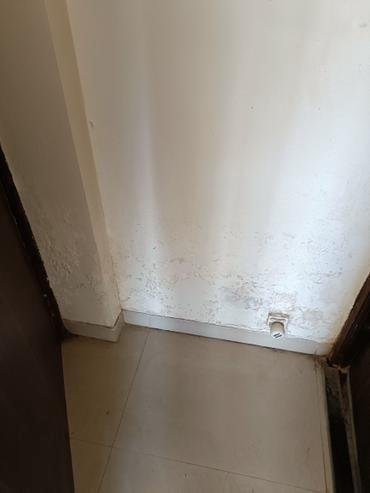
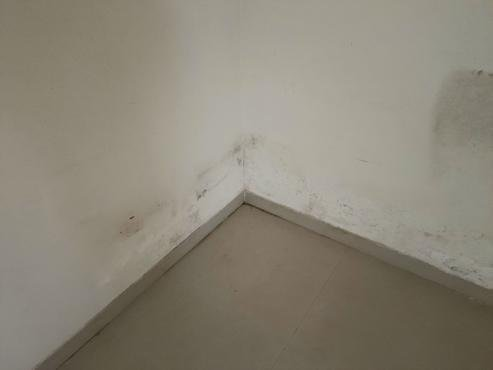
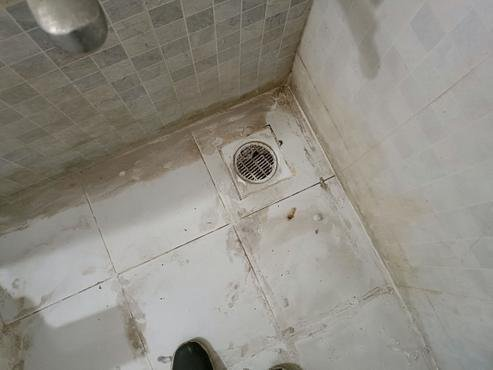
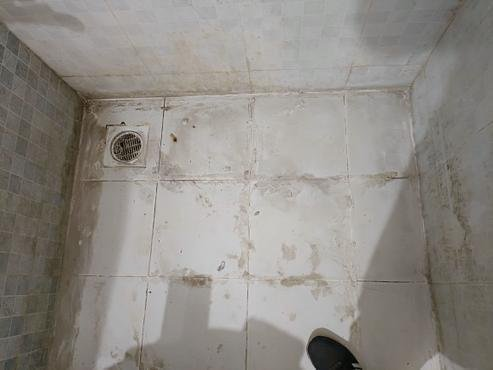
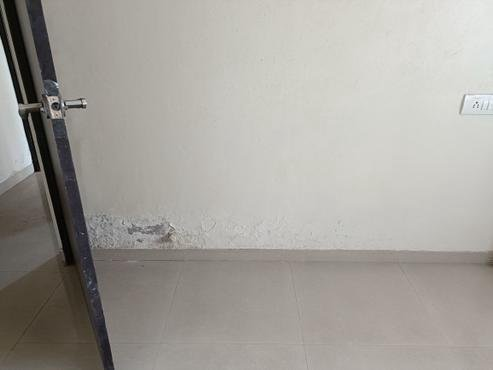
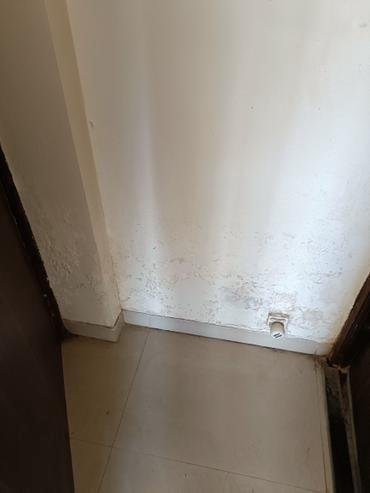
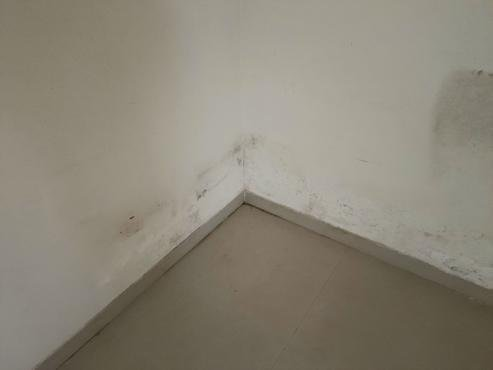
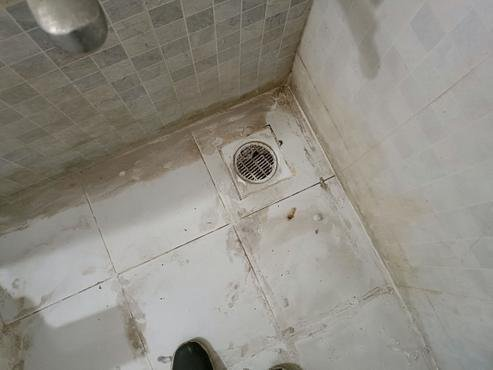
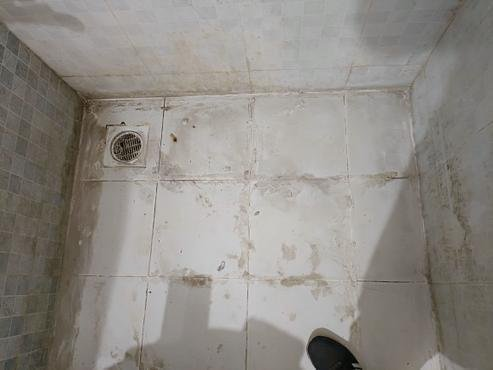
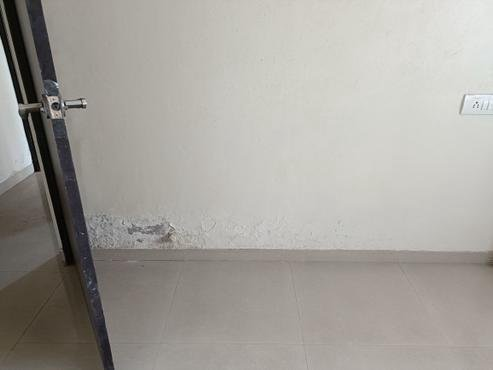
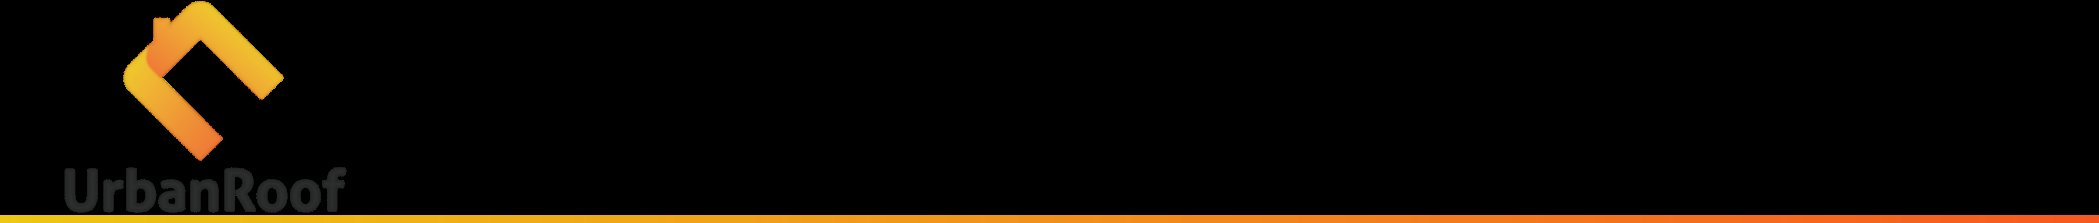
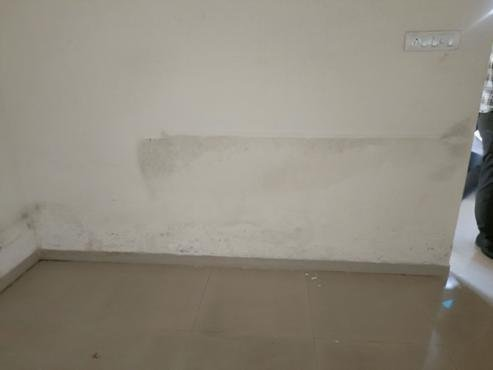
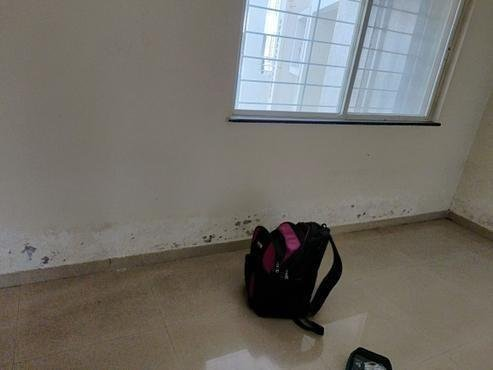


📄 Scroll up to see the rendered report. The PDF will be generated next.


In [ ]:
# ============================================================
# CELL 8: Generate Professional HTML Report (Fixed Display)
# ============================================================
from IPython.display import display, HTML
import html as html_escape

# Create image lookup dictionary
img_by_id = {img['id']: img for img in all_images}

def embed_image(img_id, max_width=250):
    """Return HTML img tag if image exists."""
    img = img_by_id.get(img_id)
    if not img:
        return ''
    return f'<img src="data:image/jpeg;base64,{img["b64"]}" style="max-width:{max_width}px; margin:8px; border:1px solid #ddd; border-radius:4px; box-shadow:2px 2px 5px rgba(0,0,0,0.1);" title="Inspection image" />'

def safe_text(text):
    """Escape HTML and handle None values."""
    if text is None:
        return "Not Available"
    return html_escape.escape(str(text))

# Prepare data with safe defaults
overview = safe_text(ddr_data.get('property_issue_summary', {}).get('overview', 'Not Available'))
critical_issues = ddr_data.get('property_issue_summary', {}).get('critical_issues', [])
moderate_issues = ddr_data.get('property_issue_summary', {}).get('moderate_issues', [])
critical_str = ', '.join(critical_issues) if critical_issues else 'None'
moderate_str = ', '.join(moderate_issues) if moderate_issues else 'None'

# Build HTML with improved styling and structure
html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Detailed Diagnostic Report</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 40px auto;
            max-width: 1200px;
            line-height: 1.6;
            color: #333;
            background: #fff;
        }}
        h1 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
            margin-top: 0;
        }}
        h2 {{
            color: #2980b9;
            margin-top: 30px;
            border-left: 5px solid #3498db;
            padding-left: 15px;
            background: #f8f9fa;
            line-height: 1.3;
        }}
        h3 {{
            color: #16a085;
            margin-top: 0;
            margin-bottom: 10px;
        }}
        .section {{
            margin-bottom: 30px;
        }}
        .issue-block {{
            background: #f9f9f9;
            padding: 15px 20px;
            margin: 20px 0;
            border-radius: 8px;
            border-left: 4px solid #3498db;
            box-shadow: 0 1px 3px rgba(0,0,0,0.1);
        }}
        .issue-block p {{
            margin: 8px 0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            font-size: 14px;
        }}
        th, td {{
            border: 1px solid #ddd;
            padding: 10px;
            text-align: left;
            vertical-align: top;
        }}
        th {{
            background-color: #3498db;
            color: white;
            font-weight: 600;
        }}
        tr:nth-child(even) {{
            background-color: #f2f2f2;
        }}
        .severity-critical, .severity-high {{
            color: #e74c3c;
            font-weight: bold;
        }}
        .severity-medium {{
            color: #f39c12;
            font-weight: bold;
        }}
        .severity-low {{
            color: #27ae60;
            font-weight: bold;
        }}
        .image-gallery {{
            display: flex;
            flex-wrap: wrap;
            gap: 10px;
            margin-top: 15px;
            align-items: center;
        }}
        .footer {{
            margin-top: 50px;
            padding-top: 20px;
            border-top: 1px solid #eee;
            font-size: 12px;
            text-align: center;
            color: #7f8c8d;
        }}
        @media print {{
            body {{
                margin: 20px;
            }}
            .no-print {{
                display: none;
            }}
        }}
    </style>
</head>
<body>

<h1>📋 Detailed Diagnostic Report (DDR)</h1>

<div class="section">
    <h2>1. Property Issue Summary</h2>
    <p><strong>Overview:</strong> {overview}</p>
    <p><strong>Critical Issues:</strong> {critical_str}</p>
    <p><strong>Moderate Issues:</strong> {moderate_str}</p>
</div>

<div class="section">
    <h2>2. Area-wise Observations</h2>
"""

# Add each area observation
for obs in ddr_data.get('area_wise_observations', []):
    area = safe_text(obs.get('area', 'Unknown Area'))
    issues_list = obs.get('issues', [])
    issues_str = ', '.join(issues_list) if issues_list else 'No specific issues recorded'
    description = safe_text(obs.get('detailed_description', 'Not Available'))
    thermal = safe_text(obs.get('thermal_findings', 'Not Available'))

    # Get images for this area
    img_ids = obs.get('image_ids', [])
    images_html = ''.join(embed_image(img_id) for img_id in img_ids if img_id in img_by_id)
    if not images_html:
        images_html = '<p style="color:#999; font-style:italic;">No relevant image available</p>'

    html_content += f"""
    <div class="issue-block">
        <h3>{area}</h3>
        <p><strong>Issues:</strong> {issues_str}</p>
        <p><strong>Description:</strong> {description}</p>
        <p><strong>Thermal Findings:</strong> {thermal}</p>
        <div class="image-gallery">
            {images_html}
        </div>
    </div>
    """

if not ddr_data.get('area_wise_observations'):
    html_content += '<p>No area-wise observations available.</p>'

# Section 3: Probable Root Causes
html_content += """
</div>
<div class="section">
    <h2>3. Probable Root Causes</h2>
"""
for cause in ddr_data.get('probable_root_causes', []):
    issue_area = safe_text(cause.get('issue_or_area', 'Issue'))
    root = safe_text(cause.get('root_cause', 'Not Available'))
    html_content += f"<p><strong>{issue_area}:</strong> {root}</p>"
if not ddr_data.get('probable_root_causes'):
    html_content += "<p>No root cause information available.</p>"

# Section 4: Severity Assessment
html_content += """
</div>
<div class="section">
    <h2>4. Severity Assessment</h2>
    <table>
        <thead>
            <tr><th>Area</th><th>Issue</th><th>Severity</th><th>Urgency</th><th>Reasoning</th</tr>
        </thead>
        <tbody>
"""
for sev in ddr_data.get('severity_assessment', []):
    area = safe_text(sev.get('area', 'N/A'))
    issue = safe_text(sev.get('issue', 'N/A'))
    severity = safe_text(sev.get('severity', 'N/A'))
    urgency = safe_text(sev.get('urgency', 'N/A'))
    reasoning = safe_text(sev.get('reasoning', 'N/A'))
    severity_class = severity.lower()
    html_content += f"""
            <tr>
                <td>{area}</td>
                <td>{issue}</td>
                <td class="severity-{severity_class}">{severity}</td>
                <td>{urgency}</td>
                <td>{reasoning}</td>
            </tr>
    """
if not ddr_data.get('severity_assessment'):
    html_content += '<tr><td colspan="5">No severity assessment available.</td></tr>'
html_content += """
        </tbody>
    </table>
</div>

<div class="section">
    <h2>5. Recommended Actions</h2>
"""
for act in ddr_data.get('recommended_actions', []):
    area = safe_text(act.get('area', 'Area'))
    action = safe_text(act.get('action', 'Not Available'))
    html_content += f"<p><strong>{area}:</strong> {action}</p>"
if not ddr_data.get('recommended_actions'):
    html_content += "<p>No recommended actions available.</p>"

# Section 6 & 7
additional_notes = safe_text(ddr_data.get('additional_notes', 'Not Available'))
missing_info = safe_text(ddr_data.get('missing_or_unclear_information', 'Not Available'))

html_content += f"""
</div>
<div class="section">
    <h2>6. Additional Notes</h2>
    <p>{additional_notes}</p>
</div>

<div class="section">
    <h2>7. Missing or Unclear Information</h2>
    <p>{missing_info}</p>
</div>

<div class="footer">
    <p>Generated by AI DDR System based on actual inspection documents.<br>
    This report is for informational purposes and should be verified by a qualified professional.</p>
</div>

</body>
</html>
"""

# Save and display
with open("DDR_Report.html", "w", encoding="utf-8") as f:
    f.write(html_content)
print("✅ HTML report saved as 'DDR_Report.html'")

# Display in Colab
display(HTML(html_content))
print("\n📄 Scroll up to see the rendered report. The PDF will be generated next.")

In [ ]:
# ============================================================
# CELL 9: Convert HTML to PDF and Download (Best & Reliable)
# ============================================================
import subprocess
import sys
import os

print("📄 Converting HTML to PDF...")

input_html = "DDR_Report.html"
output_pdf = "DDR_Report.pdf"

# Verify input file exists
if not os.path.exists(input_html):
    raise FileNotFoundError(f"❌ {input_html} not found. Run CELL 8 first.")

# Method 1: Try wkhtmltopdf (best for complex layouts)
def try_wkhtmltopdf():
    try:
        # Check if wkhtmltopdf is installed
        subprocess.run(["wkhtmltopdf", "--version"], capture_output=True, check=True)

        # Convert with optimal settings
        result = subprocess.run(
            [
                "wkhtmltopdf",
                "--enable-local-file-access",
                "--page-size", "A4",
                "--margin-top", "15mm",
                "--margin-bottom", "15mm",
                "--margin-left", "12mm",
                "--margin-right", "12mm",
                "--encoding", "UTF-8",
                "--disable-smart-shrinking",
                "--print-media-type",
                input_html,
                output_pdf
            ],
            capture_output=True,
            text=True,
            timeout=30
        )
        if result.returncode == 0 and os.path.exists(output_pdf) and os.path.getsize(output_pdf) > 0:
            return True
        else:
            print(f"⚠️ wkhtmltopdf failed: {result.stderr[:200]}")
            return False
    except (subprocess.CalledProcessError, FileNotFoundError, Exception) as e:
        print(f"⚠️ wkhtmltopdf not available: {e}")
        return False

# Method 2: Try weasyprint (pure Python, no external binaries)
def try_weasyprint():
    try:
        !pip install weasyprint -q
        from weasyprint import HTML, CSS
        from weasyprint.text.fonts import FontConfiguration

        font_config = FontConfiguration()
        HTML(input_html).write_pdf(
            output_pdf,
            font_config=font_config,
            presentational_hints=True
        )
        if os.path.exists(output_pdf) and os.path.getsize(output_pdf) > 0:
            return True
        return False
    except Exception as e:
        print(f"⚠️ WeasyPrint failed: {e}")
        return False

# Method 3: Simple fallback using pdfkit (if wkhtmltopdf installed but not found)
def try_pdfkit():
    try:
        !pip install pdfkit -q
        import pdfkit
        # Try to find wkhtmltopdf path automatically
        pdfkit.from_file(input_html, output_pdf, options={
            'page-size': 'A4',
            'margin-top': '15mm',
            'margin-bottom': '15mm',
            'margin-left': '12mm',
            'margin-right': '12mm',
            'encoding': "UTF-8"
        })
        if os.path.exists(output_pdf) and os.path.getsize(output_pdf) > 0:
            return True
        return False
    except Exception as e:
        print(f"⚠️ pdfkit failed: {e}")
        return False

# Try methods in order
success = False

# First install wkhtmltopdf if not present (Ubuntu/Debian)
!apt-get update -qq && apt-get install -y wkhtmltopdf > /dev/null 2>&1

if try_wkhtmltopdf():
    success = True
    print("✅ PDF generated using wkhtmltopdf")
elif try_weasyprint():
    success = True
    print("✅ PDF generated using WeasyPrint")
elif try_pdfkit():
    success = True
    print("✅ PDF generated using pdfkit")
else:
    print("❌ All PDF conversion methods failed.")
    print("💡 Your HTML report is still available as 'DDR_Report.html'")
    print("💡 You can manually convert it using any browser (File → Print → Save as PDF)")
    sys.exit(1)

# Download the PDF if generation succeeded
if success:
    from google.colab import files
    print(f"\n📥 Downloading {output_pdf}...")
    files.download(output_pdf)
    print("✅ Download complete! Check your local 'Downloads' folder.")

    # Also show file size for verification
    size_kb = os.path.getsize(output_pdf) / 1024
    print(f"📄 PDF file size: {size_kb:.1f} KB")
else:
    print("❌ PDF could not be generated. Please check the HTML file manually.")

📄 Converting HTML to PDF...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ PDF generated using wkhtmltopdf

📥 Downloading DDR_Report.pdf...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete! Check your local 'Downloads' folder.
📄 PDF file size: 417.2 KB


---
## 🔧 Troubleshooting

### Getting Free API Keys

**Groq (Recommended):**
1. https://console.groq.com → Sign up (no card)
2. API Keys → Create → Copy → paste in Cell 2

**HuggingFace:**
1. https://huggingface.co/join → Settings → Access Tokens
2. New Token (READ) → Copy → paste in Cell 2
3. Also set `AI_PROVIDER = 'huggingface'`

**Ollama (no key, local):**
1. https://ollama.com → install
2. `ollama pull llama3`
3. Set `AI_PROVIDER = 'ollama'` in Cell 2

### Common Errors
| Error | Fix |
|-------|-----|
| 401 Unauthorized | Wrong API key |
| 429 Rate Limit | Wait 60s, retry Cell 7 |
| JSON parse error | Cell 7 auto-recovers; check raw response |
| HF model loading | Wait 60s (cold start), retry |
| Ollama connection refused | Make sure `ollama serve` is running |

---
## 📐 Architecture
```
PDF Upload
    ├── pdfplumber → Text Extraction
    └── PyMuPDF   → Image Extraction
                        │
            Page-Context Image Descriptions
            (free text LLM + surrounding text)
                        │
         Free LLM: Groq / HuggingFace / Ollama
              DDR Synthesis & Generation
                        │
         ┌──────────────────────────┐
         │ DDR_Report.html          │ ← visual report with images
         │ DDR_Report_Data.json     │ ← structured data
         └──────────────────────────┘
```
✅ Zero paid APIs — works with Gemini replaced entirely.